Burgers reference data: using ../data/burgers.mat
Reference loaded:
  x: (512,) range: -1.0 to 1.0
  t: (201,) range: 0.0 to 1.0
  u_ref: (201, 512)
  u_ref min/max: -0.999995275372036 0.999995275372036
  nu: 0.003183098861837907
Sto-SQP: using ../1/theta_star_pointwise_jitter_1e-5.npz.npy
Sto-SQP: loaded ../1/theta_star_pointwise_jitter_1e-5.npz.npy, theta size=1981
Deterministic SQP: using ../theta_star_pointwise_jitter_1e-5.npz.npy
Deterministic SQP: loaded ../theta_star_pointwise_jitter_1e-5.npz.npy, theta size=1981
ALM: using ../theta_traditional_alm_burgers_lbfgs_20000_best.npy
ALM: loaded ../theta_traditional_alm_burgers_lbfgs_20000_best.npy, theta size=1981
Adam: using ../burgers_adam_theta.npy
Adam: loaded ../burgers_adam_theta.npy, theta size=7851

================ FULL-GRID METRICS ================
Sto-SQP              MSE = 1.441166e-07, relL2 = 6.188130e-04
Deterministic SQP    MSE = 1.927610e-05, relL2 = 7.156688e-03
ALM                  MSE = 4.005298e-06, relL2 = 3.2622

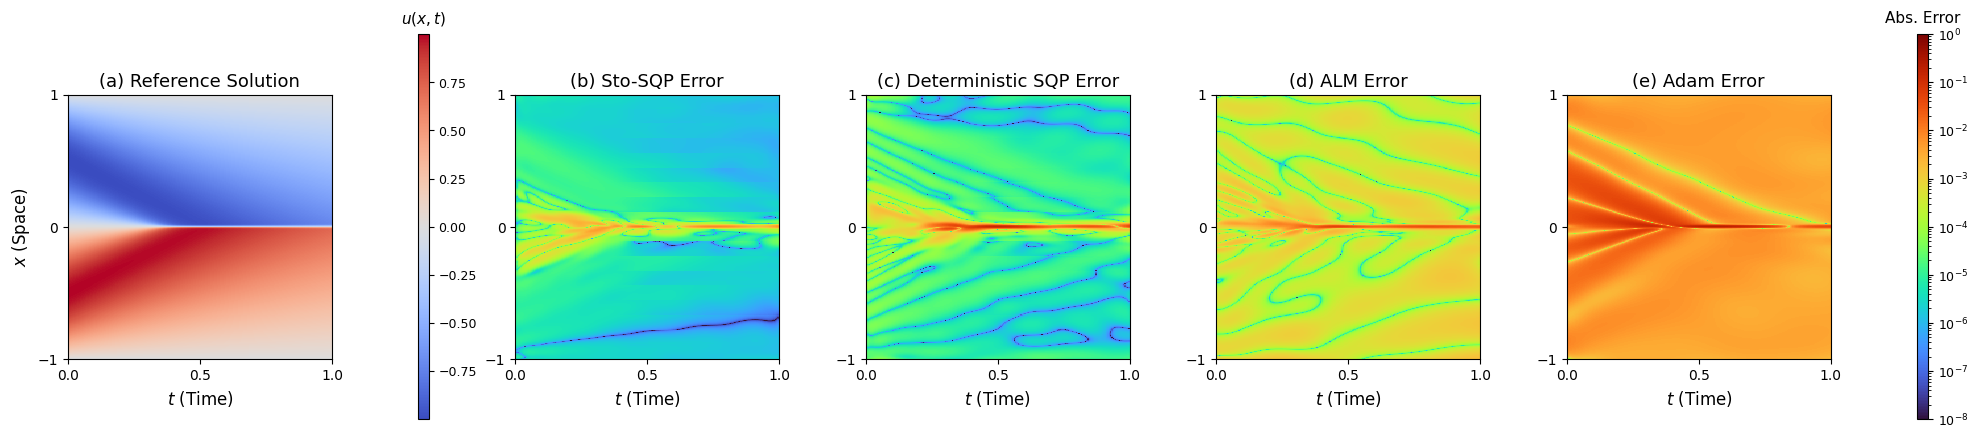

In [7]:
import os
from pathlib import Path

import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ============================================================
# USER SETTINGS
# ============================================================

# Run this from:
#   main/heatmaps/

# ------------------------------------------------------------
# Reference Burgers data
# ------------------------------------------------------------
REF_CANDIDATES = [
    "data/burgers.mat",
    "../1/data/burgers.mat",
    "../data/burgers.mat",
    "../1/burgers.mat",
    "../burgers.mat",
]
# ------------------------------------------------------------
# Model files
# ------------------------------------------------------------

# Sto-SQP is in folder 1.
# Because np.save("xxx.npz", arr) often creates "xxx.npz.npy",
# include both names.
STO_SQP_CANDIDATES = [
    "../1/theta_star_pointwise_jitter_1e-5.npz.npy",
    "../1/theta_star_pointwise_jitter_1e-5.npy",
    "../1/theta_star_pointwise_jitter_1e-5.npz",
]

# Deterministic SQP is in main folder, not folder 1.
DET_SQP_CANDIDATES = [
    "../theta_star_pointwise_jitter_1e-5.npz.npy",

]

# ALM is in folder 1 according to you.
ALM_CANDIDATES = [
    "../1/theta_traditional_alm_burgers_lbfgs_20000_best.npy",
    "../1/theta_traditional_alm_burgers_lbfgs_20000_final.npy",
    "../1/traditional_alm_burgers_best.npy",
    "../1/traditional_alm_burgers_final.npy",
    "../theta_traditional_alm_burgers_lbfgs_20000_best.npy",
]

# Adam is in folder 1 according to you.
ADAM_CANDIDATES = [
    "../1/burgers_adam_theta.npy",
    "../burgers_adam_theta.npy",
]

SAVE_PREFIX = "burgers_reference_plus_4_errors"

# ------------------------------------------------------------
# Architecture
# ------------------------------------------------------------
# SQP / ALM Burgers from your code style: [2] + [30]*3 + [1]
SQP_LAYER_SIZES  = [2, 30, 30, 30, 1]
ALM_LAYER_SIZES  = [2, 30, 30, 30, 1]

# Adam Burgers from your Adam code: hidden_dim=50, num_hidden=4
ADAM_LAYER_SIZES = [2, 50, 50, 50, 50, 1]

SQP_ACTIVATION  = "tanh"
ALM_ACTIVATION  = "tanh"
ADAM_ACTIVATION = "tanh"

# IMPORTANT:
# Your Burgers SQP logs said input normalization ON.
# Set this True unless you know your saved theta was trained without normalization.
NORMALIZE_INPUT = False

# Colormap setup
REF_CMAP = "coolwarm"
ERR_CMAP = "turbo"

# Error log scale
ERR_VMIN = 1e-8

FIG_DPI = 300


# ============================================================
# FILE HELPERS
# ============================================================

def find_existing_file(candidates, name):
    for p in candidates:
        if Path(p).exists():
            print(f"{name}: using {p}")
            return p

    raise FileNotFoundError(
        f"Could not find {name}. Tried:\n" + "\n".join(candidates)
    )


def load_theta(candidates, name):
    path = find_existing_file(candidates, name)
    obj = np.load(path, allow_pickle=True)

    # Most of your files are plain theta arrays.
    # If npz, try common keys.
    if hasattr(obj, "files"):
        keys = obj.files
        for key in ["theta", "theta_star", "params_flat"]:
            if key in keys:
                theta = np.asarray(obj[key], dtype=np.float64).reshape(-1)
                print(f"{name}: loaded {path}, key={key}, theta size={theta.size}")
                return path, theta
        raise KeyError(f"{path} is npz with keys {keys}, but no theta key found.")

    theta = np.asarray(obj, dtype=np.float64).reshape(-1)
    print(f"{name}: loaded {path}, theta size={theta.size}")
    return path, theta


# ============================================================
# REFERENCE DATA
# ============================================================

def load_burgers_reference():
    path = find_existing_file(REF_CANDIDATES, "Burgers reference data")
    data = scipy.io.loadmat(path)

    t = np.asarray(data["t"]).squeeze().astype(np.float64)
    x = np.asarray(data["x"]).squeeze().astype(np.float64)
    u_ref = np.asarray(data["usol"], dtype=np.float64)

    if u_ref.shape == (len(x), len(t)):
        u_ref = u_ref.T

    if u_ref.shape != (len(t), len(x)):
        raise ValueError(
            f"Reference shape mismatch: usol.shape={u_ref.shape}, "
            f"expected {(len(t), len(x))}"
        )

    nu = None
    if "nu" in data:
        nu = float(np.asarray(data["nu"]).squeeze())

    print("Reference loaded:")
    print("  x:", x.shape, "range:", float(x[0]), "to", float(x[-1]))
    print("  t:", t.shape, "range:", float(t[0]), "to", float(t[-1]))
    print("  u_ref:", u_ref.shape)
    print("  u_ref min/max:", float(np.min(u_ref)), float(np.max(u_ref)))
    if nu is not None:
        print("  nu:", nu)

    return x, t, u_ref


# ============================================================
# MLP HELPERS
# ============================================================

def normalize_xt(X, x_min, x_max, t_min, t_max):
    x = X[:, 0:1]
    t = X[:, 1:2]

    x_n = 2.0 * (x - x_min) / (x_max - x_min + 1e-30) - 1.0
    t_n = 2.0 * (t - t_min) / (t_max - t_min + 1e-30) - 1.0

    return np.concatenate([x_n, t_n], axis=1)


def activate(z, name):
    if name == "tanh":
        return np.tanh(z)
    elif name == "silu":
        return z / (1.0 + np.exp(-z))
    elif name == "relu":
        return np.maximum(z, 0.0)
    elif name == "gelu":
        return 0.5 * z * (
            1.0 + np.tanh(np.sqrt(2.0 / np.pi) * (z + 0.044715 * z ** 3))
        )
    else:
        raise ValueError(f"Unsupported activation: {name}")


def unflatten_theta(theta, layer_sizes):
    theta = np.asarray(theta, dtype=np.float64).reshape(-1)
    params = []
    idx = 0

    for m, n in zip(layer_sizes[:-1], layer_sizes[1:]):
        w_size = m * n
        b_size = n

        W = theta[idx:idx + w_size].reshape(m, n)
        idx += w_size

        b = theta[idx:idx + b_size].reshape(1, n)
        idx += b_size

        params.append((W, b))

    if idx != theta.size:
        raise ValueError(
            f"Did not consume all theta entries: used {idx}, total {theta.size}.\n"
            f"Layer sizes = {layer_sizes}"
        )

    return params


def mlp_predict(theta, layer_sizes, X, activation, normalize_input, x_min, x_max, t_min, t_max):
    params = unflatten_theta(theta, layer_sizes)

    H = np.asarray(X, dtype=np.float64)

    if normalize_input:
        H = normalize_xt(H, x_min, x_max, t_min, t_max)

    for i, (W, b) in enumerate(params):
        H = H @ W + b
        if i < len(params) - 1:
            H = activate(H, activation)

    return H[:, 0]


def predict_on_grid(theta, layer_sizes, x, t, activation="tanh", normalize_input=True):
    """
    Returns u_pred with shape (nt, nx).
    Input order: [x,t].
    """
    TT, XX = np.meshgrid(t, x, indexing="ij")

    X_eval = np.stack(
        [XX.reshape(-1), TT.reshape(-1)],
        axis=1,
    )

    u_pred = mlp_predict(
        theta=theta,
        layer_sizes=layer_sizes,
        X=X_eval,
        activation=activation,
        normalize_input=normalize_input,
        x_min=float(x[0]),
        x_max=float(x[-1]),
        t_min=float(t[0]),
        t_max=float(t[-1]),
    )

    return u_pred.reshape(len(t), len(x))


def mse(a, b):
    return float(np.mean((a - b) ** 2))


def rel_l2(a, b):
    return float(np.linalg.norm(a - b) / (np.linalg.norm(b) + 1e-12))


# ============================================================
# PLOTTING
# ============================================================

def make_figure(x, t, u_ref, err_dict, metric_dict):
    # --------------------------------------------------------
    # Shared color scales
    # --------------------------------------------------------
    ref_vabs = np.max(np.abs(u_ref))
    ref_vmin = -ref_vabs
    ref_vmax =  ref_vabs

    overall_err_max = max(float(np.max(v)) for v in err_dict.values())
    err_vmax = max(1.0, overall_err_max)

    extent = [t[0], t[-1], x[0], x[-1]]

    # --------------------------------------------------------
    # Figure layout
    # [ref] [ref cbar] [sto] [det] [alm] [adam] [err cbar]
    # --------------------------------------------------------
    fig = plt.figure(figsize=(24, 5.0))

    gs = fig.add_gridspec(
        1,
        7,
        width_ratios=[1.0, 0.04, 1.0, 1.0, 1.0, 1.0, 0.04],
        wspace=0.45,
    )

    ax_ref  = fig.add_subplot(gs[0, 0])
    cax_ref = fig.add_subplot(gs[0, 1])

    ax_sto  = fig.add_subplot(gs[0, 2])
    ax_det  = fig.add_subplot(gs[0, 3])
    ax_alm  = fig.add_subplot(gs[0, 4])
    ax_adam = fig.add_subplot(gs[0, 5])

    cax_err = fig.add_subplot(gs[0, 6])

    # --------------------------------------------------------
    # Reference solution
    # --------------------------------------------------------
    im_ref = ax_ref.imshow(
        u_ref.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=REF_CMAP,
        vmin=ref_vmin,
        vmax=ref_vmax,
        interpolation="nearest",
    )

    cb_ref = fig.colorbar(im_ref, cax=cax_ref)
    cb_ref.ax.set_title(r"$u(x,t)$", fontsize=11, pad=8)
    cb_ref.ax.tick_params(labelsize=9)

    ax_ref.set_title("(a) Reference Solution", fontsize=13)

    # --------------------------------------------------------
    # Error heatmaps
    # --------------------------------------------------------
    err_norm = LogNorm(vmin=ERR_VMIN, vmax=err_vmax)

    panels = [
        (ax_sto,  "(b) Sto-SQP Error",            err_dict["Sto-SQP"]),
        (ax_det,  "(c) Deterministic SQP Error",  err_dict["Deterministic SQP"]),
        (ax_alm,  "(d) ALM Error",                err_dict["ALM"]),
        (ax_adam, "(e) Adam Error",               err_dict["Adam"]),
    ]

    last_im = None

    for ax, title, err in panels:
        err_plot = np.maximum(err.T, ERR_VMIN)

        last_im = ax.imshow(
            err_plot,
            origin="lower",
            aspect="auto",
            extent=extent,
            cmap=ERR_CMAP,
            norm=err_norm,
            interpolation="nearest",
        )

        ax.set_title(title, fontsize=13)

    cb_err = fig.colorbar(last_im, cax=cax_err)
    cb_err.ax.set_title("Abs. Error", fontsize=11, pad=8)
    cb_err.ax.tick_params(labelsize=9)

    # --------------------------------------------------------
    # Axis formatting
    # --------------------------------------------------------
    all_axes = [ax_ref, ax_sto, ax_det, ax_alm, ax_adam]

    for ax in all_axes:
        ax.set_xlabel(r"$t$ (Time)", fontsize=12)
        ax.set_xlim(t[0], t[-1])
        ax.set_ylim(x[0], x[-1])
        ax.set_xticks([float(t[0]), 0.5 * (float(t[0]) + float(t[-1])), float(t[-1])])
        ax.set_yticks([float(x[0]), 0.0, float(x[-1])])
        ax.tick_params(labelsize=10)
        ax.set_box_aspect(1)

    ax_ref.set_ylabel(r"$x$ (Space)", fontsize=12)

    for ax in [ax_sto, ax_det, ax_alm, ax_adam]:
        ax.set_ylabel("")

    # --------------------------------------------------------
    # Print metrics
    # --------------------------------------------------------
    print("\nFigure metrics:")
    for name in ["Sto-SQP", "Deterministic SQP", "ALM", "Adam"]:
        print(
            f"{name:20s} MSE={metric_dict[name]['mse']:.6e}, "
            f"relL2={metric_dict[name]['relL2']:.6e}"
        )

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------
    fig.savefig(f"{SAVE_PREFIX}.png", dpi=FIG_DPI, bbox_inches="tight")
    fig.savefig(f"{SAVE_PREFIX}.pdf", bbox_inches="tight")

    print(f"\nSaved figure -> {SAVE_PREFIX}.png")
    print(f"Saved figure -> {SAVE_PREFIX}.pdf")

    plt.show()


# ============================================================
# MAIN
# ============================================================

def main():
    # --------------------------------------------------------
    # Load reference
    # --------------------------------------------------------
    x, t, u_ref = load_burgers_reference()

    # --------------------------------------------------------
    # Load model theta
    # --------------------------------------------------------
    sto_path, theta_sto = load_theta(STO_SQP_CANDIDATES, "Sto-SQP")
    det_path, theta_det = load_theta(DET_SQP_CANDIDATES, "Deterministic SQP")
    alm_path, theta_alm = load_theta(ALM_CANDIDATES, "ALM")
    adam_path, theta_adam = load_theta(ADAM_CANDIDATES, "Adam")

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------
    u_sto = predict_on_grid(
        theta_sto,
        SQP_LAYER_SIZES,
        x,
        t,
        activation=SQP_ACTIVATION,
        normalize_input=NORMALIZE_INPUT,
    )

    u_det = predict_on_grid(
        theta_det,
        SQP_LAYER_SIZES,
        x,
        t,
        activation=SQP_ACTIVATION,
        normalize_input=NORMALIZE_INPUT,
    )

    u_alm = predict_on_grid(
        theta_alm,
        ALM_LAYER_SIZES,
        x,
        t,
        activation=ALM_ACTIVATION,
        normalize_input=NORMALIZE_INPUT,
    )

    u_adam = predict_on_grid(
        theta_adam,
        ADAM_LAYER_SIZES,
        x,
        t,
        activation=ADAM_ACTIVATION,
        normalize_input=NORMALIZE_INPUT,
    )

    # --------------------------------------------------------
    # Errors
    # --------------------------------------------------------
    err_sto  = np.abs(u_sto  - u_ref)
    err_det  = np.abs(u_det  - u_ref)
    err_alm  = np.abs(u_alm  - u_ref)
    err_adam = np.abs(u_adam - u_ref)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------
    metric_dict = {
        "Sto-SQP": {
            "mse": mse(u_sto, u_ref),
            "relL2": rel_l2(u_sto, u_ref),
        },
        "Deterministic SQP": {
            "mse": mse(u_det, u_ref),
            "relL2": rel_l2(u_det, u_ref),
        },
        "ALM": {
            "mse": mse(u_alm, u_ref),
            "relL2": rel_l2(u_alm, u_ref),
        },
        "Adam": {
            "mse": mse(u_adam, u_ref),
            "relL2": rel_l2(u_adam, u_ref),
        },
    }

    print("\n================ FULL-GRID METRICS ================")
    for name, m in metric_dict.items():
        print(f"{name:20s} MSE = {m['mse']:.6e}, relL2 = {m['relL2']:.6e}")

    err_dict = {
        "Sto-SQP": err_sto,
        "Deterministic SQP": err_det,
        "ALM": err_alm,
        "Adam": err_adam,
    }

    make_figure(x, t, u_ref, err_dict, metric_dict)


if __name__ == "__main__":
    main()

In [8]:
# ============================================================
# Burgers error analysis near the middle shock layer x = 0
# Run after your heatmap code, where these exist:
# x, t, u_ref, u_sto, u_det, u_alm, u_adam
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

methods = {
    "Sto-SQP": u_sto,
    "Deterministic SQP": u_det,
    "ALM": u_alm,
    "Adam": u_adam,
}

band_widths = [0.02, 0.05, 0.10, 0.20]

print("========== Error near Burgers middle layer x = 0 ==========")

for bw in band_widths:
    mask_mid = np.abs(x) <= bw
    mask_out = ~mask_mid

    print(f"\nShock band: |x| <= {bw}")

    for name, upred in methods.items():
        err2 = (upred - u_ref) ** 2
        abs_err = np.abs(upred - u_ref)

        mse_all = np.mean(err2)
        mse_mid = np.mean(err2[:, mask_mid])
        mse_out = np.mean(err2[:, mask_out])

        max_mid = np.max(abs_err[:, mask_mid])
        p95_mid = np.percentile(abs_err[:, mask_mid], 95)

        print(
            f"{name:20s} "
            f"MSE_all={mse_all:.3e}  "
            f"MSE_mid={mse_mid:.3e}  "
            f"MSE_out={mse_out:.3e}  "
            f"p95_mid={p95_mid:.3e}  "
            f"max_mid={max_mid:.3e}"
        )

NameError: name 'u_sto' is not defined